# Lattice Import and Transformations

**Model.** This notebook exports and reimports a labeled finite lattice, then applies immutable subgraph, vacancy, boundary-condition, and seeded-disorder transformations before constructing tight-binding models.

**Typical uses.** Bringing coordinate and edge data into the package, preserving labels and units, creating defects or fragments, recording transformation provenance, and comparing reproducible disorder realizations.

**Parameters.** Site and bond CSV files carry geometry and complex matrix elements; a JSON sidecar carries conventions and provenance. Transformations return new `LatticeSpec` values and append ordered provenance records.

**Useful plots.** Lattice graphs compare the imported geometry with a vacancy and a reproducibly disordered bond realization.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from quantum_lattice_models import (
    LatticeSpec,
    apply_bond_disorder,
    apply_onsite_disorder,
    create_model_spec,
    export_lattice_csv,
    import_lattice_csv,
    lattice_subgraph,
    remove_lattice_sites,
    with_boundary_conditions,
)
from quantum_lattice_models.lattice import Bond
from quantum_lattice_models.plotting import plot_interaction_graph

repository_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
output_dir = repository_root / "results/notebooks/lattice_import"
output_dir.mkdir(parents=True, exist_ok=True)

In [2]:
original = LatticeSpec(
    n_sites=6,
    positions=((0.0, 0.0), (1.0, 0.0), (2.0, 0.0), (2.0, 1.0), (1.0, 1.0), (0.0, 1.0)),
    bonds=(
        Bond(0, 1, -1.0),
        Bond(1, 2, -1.0),
        Bond(2, 3, -1.0),
        Bond(3, 4, -1.0),
        Bond(4, 5, -1.0),
        Bond(5, 0, -1.0),
        Bond(1, 4, 0.25j),
    ),
    site_labels=("A", "B", "C", "D", "E", "F"),
    unit_cells=(0, 0, 1, 1, 2, 2),
    units={"position": "lattice_constant", "energy": "eV"},
    conventions={"bond_values": "explicit matrix elements"},
    provenance=({"operation": "notebook_source", "parameters": {}},),
)
sites_path, bonds_path, metadata_path = export_lattice_csv(
    original,
    output_dir / "sites.csv",
    output_dir / "bonds.csv",
)
restored = import_lattice_csv(sites_path, bonds_path, metadata_path=metadata_path)

print("CSV lattice round trip")
print(f"  specifications equal: {restored == original}")
print(f"  sites: {restored.n_sites}")
print(f"  bonds: {len(restored.bonds)}")
print(f"  units: {restored.units}")

CSV lattice round trip
  specifications equal: True
  sites: 6
  bonds: 7
  units: {'energy': 'eV', 'position': 'lattice_constant'}


In [3]:
fragment = lattice_subgraph(restored, [0, 1, 4, 5])
vacancy = remove_lattice_sites(restored, [2])
periodic_metadata = with_boundary_conditions(vacancy, {"x": "periodic"})
onsite_disorder = apply_onsite_disorder(restored, strength=0.35, seed=12)
bond_disorder = apply_bond_disorder(restored, strength=0.15, seed=9)

print("Transformation summary")
print(f"  fragment sites/bonds: {fragment.n_sites}/{len(fragment.bonds)}")
print(f"  vacancy sites/bonds: {vacancy.n_sites}/{len(vacancy.bonds)}")
print(f"  boundary metadata: {periodic_metadata.boundary_conditions}")
print(
    "  onsite disorder reproducible:",
    onsite_disorder == apply_onsite_disorder(restored, strength=0.35, seed=12),
)
print(
    f"  provenance operations: {[record['operation'] for record in periodic_metadata.provenance]}"
)

Transformation summary
  fragment sites/bonds: 4/4
  vacancy sites/bonds: 5/5
  boundary metadata: {'x': 'periodic'}
  onsite disorder reproducible: True
  provenance operations: ['notebook_source', 'remove_sites', 'set_boundary_conditions']


In [4]:
models = {
    "Imported": create_model_spec(
        "custom_tight_binding",
        lattice=restored,
        parameters={"hopping": 1.0, "onsite": 0.0, "hermitian": True},
    ),
    "Vacancy": create_model_spec(
        "custom_tight_binding",
        lattice=vacancy,
        parameters={"hopping": 1.0, "onsite": 0.0, "hermitian": True},
    ),
    "Bond disorder": create_model_spec(
        "custom_tight_binding",
        lattice=bond_disorder,
        parameters={"hopping": 1.0, "onsite": 0.0, "hermitian": True},
    ),
}

for label, model in models.items():
    print(f"{label:<14s} shape={model.hamiltonian().shape}, interactions={len(model.interactions)}")

Imported       shape=(6, 6), interactions=7
Vacancy        shape=(5, 5), interactions=5
Bond disorder  shape=(6, 6), interactions=7


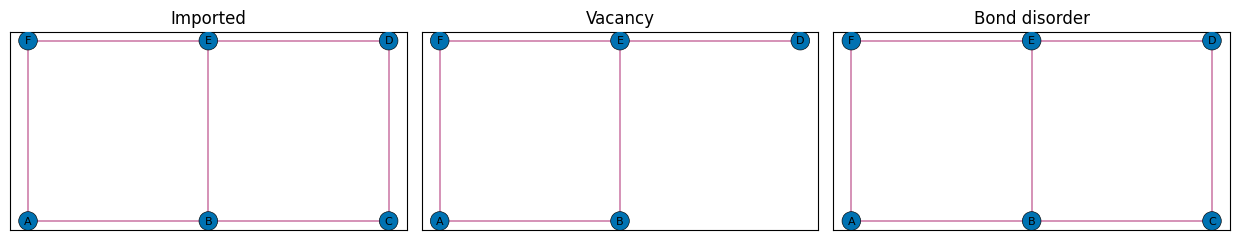

In [5]:
figure, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
for ax, (label, model) in zip(axes, models.items(), strict=True):
    plot_interaction_graph(model, ax=ax, show_coefficients=False)
    ax.set_title(label)
figure.tight_layout()

Transformations are immutable: the imported source remains unchanged, while each derived lattice carries the ordered operations and parameters needed to explain how its geometry or couplings were produced.